# Suspect Alignment as Story Unfolds — Qwen 2.5 1.5B
### Real model · No quantization · No auth needed

---
**Core question:** As we feed the model each new piece of evidence, does the final-layer hidden state `x⁽ᴸ⁾` drift toward the correct suspect's name embedding?

**Method:**
- 7 forward passes, one per story checkpoint (intro → crime → alibis → Michael seen → conclusion)
- Each pass: read `x⁽ᴸ⁾` = last layer, last token position
- Measure `cos(x⁽ᴸ⁾, e_John)`, `cos(x⁽ᴸ⁾, e_Michael)`, `cos(x⁽ᴸ⁾, e_Sarah)` where `e_name` = input embedding vector
- Plot how alignment shifts at each evidence event

**Expected result:** Michael's curve rises, John and Sarah drop after their alibis.

---
## ✅ Setup
1. `Runtime → Change runtime type → T4 GPU`
2. No HuggingFace token needed
---

In [ ]:
# ── Cell 1: Install ───────────────────────────────────────────────────────────
!pip install -q transformers>=4.42.0 accelerate>=0.30.0

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [ ]:
# ── Cell 2: Load Qwen 2.5 1.5B in fp16 (no quantization needed, ~3 GB VRAM) ──
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = 'Qwen/Qwen2.5-1.5B'

print('Loading tokenizer ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print('Loading model in fp16 ... (~1.5 GB download, ~1 min)')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
    output_hidden_states=True,
)
model.eval()

n_layers = model.config.num_hidden_layers
d_model  = model.config.hidden_size
print(f'\n✅ Loaded  |  layers={n_layers}  d_model={d_model}')
# Qwen 2.5 1.5B: 28 layers, d_model=1536

Loading tokenizer ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]


✅ Loaded  |  layers=28  d_model=1536


In [ ]:
# ── Cell 3: Get name embedding vectors ───────────────────────────────────────
import numpy as np

E = model.get_input_embeddings().weight.float().detach().cpu().numpy()
print(f'Embedding matrix : {E.shape}')

NAMES    = ['John', 'Michael', 'Sarah']
MURDERER = 'Michael'
PALETTE  = {'John': '#457b9d', 'Michael': '#e63946', 'Sarah': '#2a9d8f'}

def get_token_id(word):
    for candidate in [' ' + word, word]:
        ids = tokenizer.encode(candidate, add_special_tokens=False)
        if ids:
            tid = ids[0]
            print(f"  '{word}' → token {tid}  ('{tokenizer.decode([tid])}')")
            return tid

print('Name token IDs:')
name_ids  = {name: get_token_id(name) for name in NAMES}
name_embs = {name: E[name_ids[name]]  for name in NAMES}

# Sanity: cosine similarity between name embeddings
print('\nPairwise cosine similarity between name embeddings:')
for i, n1 in enumerate(NAMES):
    for n2 in NAMES[i+1:]:
        e1 = name_embs[n1] / (np.linalg.norm(name_embs[n1]) + 1e-8)
        e2 = name_embs[n2] / (np.linalg.norm(name_embs[n2]) + 1e-8)
        print(f'  sim({n1}, {n2}) = {float(e1 @ e2):.4f}')

Embedding matrix : (151936, 1536)
Name token IDs:
  'John' → token 3757  (' John')
  'Michael' → token 7937  (' Michael')
  'Sarah' → token 20445  (' Sarah')

Pairwise cosine similarity between name embeddings:
  sim(John, Michael) = 0.1864
  sim(John, Sarah) = 0.1701
  sim(Michael, Sarah) = 0.1368


In [ ]:
# ── Cell 4: Define story checkpoints ─────────────────────────────────────────
# Each checkpoint is a progressively longer story prefix.
# The model sees only what a reader would know at that point.

CHECKPOINTS = [
    (
        'Intro\n(three suspects)',
        'There was an old townhouse at the end of a quiet street. '
        'Three people lived there: John, Michael, and Sarah. '
        'They had shared the house for years, though lately the atmosphere '
        'had become tense after several arguments about money that had gone missing.'
    ),
    (
        'Crime\n(crash, police)',
        'There was an old townhouse at the end of a quiet street. '
        'Three people lived there: John, Michael, and Sarah. '
        'They had shared the house for years, though lately the atmosphere '
        'had become tense after several arguments about money that had gone missing. '
        'One evening the neighbors heard a loud crash followed by silence. '
        'The police arrived later that night to find a terrible crime had taken place inside.'
    ),
    (
        "John's alibi\n(visiting relatives)",
        'There was an old townhouse at the end of a quiet street. '
        'Three people lived there: John, Michael, and Sarah. '
        'They had shared the house for years, though lately the atmosphere '
        'had become tense after several arguments about money that had gone missing. '
        'One evening the neighbors heard a loud crash followed by silence. '
        'The police arrived later that night to find a terrible crime had taken place inside. '
        'John had been visiting relatives in another town that entire day and '
        'multiple witnesses confirmed he never left.'
    ),
    (
        "Sarah's alibi\n(conference, records)",
        'There was an old townhouse at the end of a quiet street. '
        'Three people lived there: John, Michael, and Sarah. '
        'They had shared the house for years, though lately the atmosphere '
        'had become tense after several arguments about money that had gone missing. '
        'One evening the neighbors heard a loud crash followed by silence. '
        'The police arrived later that night to find a terrible crime had taken place inside. '
        'John had been visiting relatives in another town that entire day and '
        'multiple witnesses confirmed he never left. '
        'Sarah was attending a conference several hours away and had '
        'train records and hotel receipts confirming her alibi beyond any doubt.'
    ),
    (
        'Physical evidence\n(footprints, struggle)',
        'There was an old townhouse at the end of a quiet street. '
        'Three people lived there: John, Michael, and Sarah. '
        'They had shared the house for years, though lately the atmosphere '
        'had become tense after several arguments about money that had gone missing. '
        'One evening the neighbors heard a loud crash followed by silence. '
        'The police arrived later that night to find a terrible crime had taken place inside. '
        'John had been visiting relatives in another town that entire day and '
        'multiple witnesses confirmed he never left. '
        'Sarah was attending a conference several hours away and had '
        'train records and hotel receipts confirming her alibi beyond any doubt. '
        'When the detectives examined the house, they noticed signs of a struggle in the study '
        'and found a set of muddy footprints leading from the garden door to the hallway.'
    ),
    (
        'Michael seen\n(garden gate)',
        'There was an old townhouse at the end of a quiet street. '
        'Three people lived there: John, Michael, and Sarah. '
        'They had shared the house for years, though lately the atmosphere '
        'had become tense after several arguments about money that had gone missing. '
        'One evening the neighbors heard a loud crash followed by silence. '
        'The police arrived later that night to find a terrible crime had taken place inside. '
        'John had been visiting relatives in another town that entire day and '
        'multiple witnesses confirmed he never left. '
        'Sarah was attending a conference several hours away and had '
        'train records and hotel receipts confirming her alibi beyond any doubt. '
        'When the detectives examined the house, they noticed signs of a struggle in the study '
        'and found a set of muddy footprints leading from the garden door to the hallway. '
        'Earlier that evening, one of the neighbors recalled seeing Michael '
        'returning through the garden gate shortly before the incident occurred.'
    ),
    (
        'Conclusion prompt\n("the murderer was")',
        'There was an old townhouse at the end of a quiet street. '
        'Three people lived there: John, Michael, and Sarah. '
        'They had shared the house for years, though lately the atmosphere '
        'had become tense after several arguments about money that had gone missing. '
        'One evening the neighbors heard a loud crash followed by silence. '
        'The police arrived later that night to find a terrible crime had taken place inside. '
        'John had been visiting relatives in another town that entire day and '
        'multiple witnesses confirmed he never left. '
        'Sarah was attending a conference several hours away and had '
        'train records and hotel receipts confirming her alibi beyond any doubt. '
        'When the detectives examined the house, they noticed signs of a struggle in the study '
        'and found a set of muddy footprints leading from the garden door to the hallway. '
        'Earlier that evening, one of the neighbors recalled seeing Michael '
        'returning through the garden gate shortly before the incident occurred. '
        'After carefully reviewing all the evidence, the investigators '
        'concluded that the murderer was'
    ),
]

print(f'{len(CHECKPOINTS)} checkpoints defined')
for i, (lbl, txt) in enumerate(CHECKPOINTS):
    n = tokenizer(txt, return_tensors='pt')['input_ids'].shape[1]
    print(f'  [{i+1}] {lbl.split(chr(10))[0]:<35} {n} tokens')

7 checkpoints defined
  [1] Intro                               51 tokens
  [2] Crime                               79 tokens
  [3] John's alibi                        98 tokens
  [4] Sarah's alibi                       121 tokens
  [5] Physical evidence                   154 tokens
  [6] Michael seen                        176 tokens
  [7] Conclusion prompt                   190 tokens


In [ ]:
# ── Cell 5: Forward pass at every checkpoint ──────────────────────────────────
# No signal injection — these are pure real model activations.

def cosine_sim(a, b):
    a = a / (np.linalg.norm(a) + 1e-8)
    b = b / (np.linalg.norm(b) + 1e-8)
    return float(a @ b)

results = []

print('Running forward passes ...')
print(f'{"":36} {"John":>8} {"Michael":>9} {"Sarah":>8}  Leading')
print('─' * 78)

for label, text in CHECKPOINTS:
    inputs  = tokenizer(text, return_tensors='pt').to(model.device)
    seq_len = inputs['input_ids'].shape[1]

    with torch.no_grad():
        out = model(**inputs)

    # Last layer, last token → (d_model,)
    x_final = out.hidden_states[-1][0, -1, :].float().cpu().numpy()

    sims   = {name: cosine_sim(x_final, name_embs[name]) for name in NAMES}
    dists  = {name: 1.0 - sims[name] for name in NAMES}
    winner = max(sims, key=sims.get)

    # Top-3 next token predictions
    logits = out.logits[0, -1, :].float()
    probs  = torch.softmax(logits, dim=-1)
    top3   = torch.topk(probs, 3)
    top3_preds = [(tokenizer.decode([t]).strip(), float(p))
                  for t, p in zip(top3.indices.tolist(), top3.values.tolist())]

    results.append({
        'label':   label,
        'seq_len': seq_len,
        'sims':    sims,
        'dists':   dists,
        'winner':  winner,
        'top3':    top3_preds,
    })

    short = label.split('\n')[0]
    mark  = '✓' if winner == MURDERER else '✗'
    print(f'{short:<36} {sims["John"]:>8.4f} {sims["Michael"]:>9.4f} '
          f'{sims["Sarah"]:>8.4f}  {winner} {mark}')

print('\n✅ Done')

Running forward passes ...
                                         John   Michael    Sarah  Leading
──────────────────────────────────────────────────────────────────────────────
Intro                                  0.1402    0.1271   0.1312  John ✗
Crime                                  0.1327    0.1234   0.1245  John ✗
John's alibi                           0.1269    0.1362   0.1279  Michael ✓
Sarah's alibi                          0.1376    0.1500   0.1121  Michael ✓
Physical evidence                      0.1321    0.1248   0.1248  John ✗
Michael seen                           0.1251    0.1247   0.1247  John ✗
Conclusion prompt                      0.1112    0.1179   0.1119  Michael ✓

✅ Done


In [ ]:
# ── Cell 6: Print full evidence table + predictions ───────────────────────────
print('\n── Next-token predictions at each checkpoint ────────────────────────────')
for r in results:
    lbl = r['label'].replace('\n', ' ')
    preds = '  |  '.join(f"{tok} ({p:.3f})" for tok, p in r['top3'])
    print(f"  {lbl:<38} → {preds}")

print('\n── Cosine distances at final checkpoint ─────────────────────────────────')
for name in NAMES:
    d   = results[-1]['dists'][name]
    tag = '  ← closest ✓' if name == results[-1]['winner'] else ''
    print(f'  {name:<10} dist={d:.4f}{tag}')


── Next-token predictions at each checkpoint ────────────────────────────
  Intro (three suspects)                 → One (0.179)  |  John (0.135)  |  The (0.093)
  Crime (crash, police)                  → The (0.266)  |  John (0.084)  |  They (0.074)
  John's alibi (visiting relatives)      → The (0.167)  |  Michael (0.162)  |  He (0.070)
  Sarah's alibi (conference, records)    → Michael (0.465)  |  But (0.092)  |  The (0.080)
  Physical evidence (footprints, struggle) → The (0.188)  |  John (0.116)  |  They (0.104)
  Michael seen (garden gate)             → The (0.191)  |  He (0.074)  |  When (0.053)
  Conclusion prompt ("the murderer was") → none (0.230)  |  Michael (0.158)  |  most (0.055)

── Cosine distances at final checkpoint ─────────────────────────────────
  John       dist=0.8888
  Michael    dist=0.8821  ← closest ✓
  Sarah      dist=0.8881


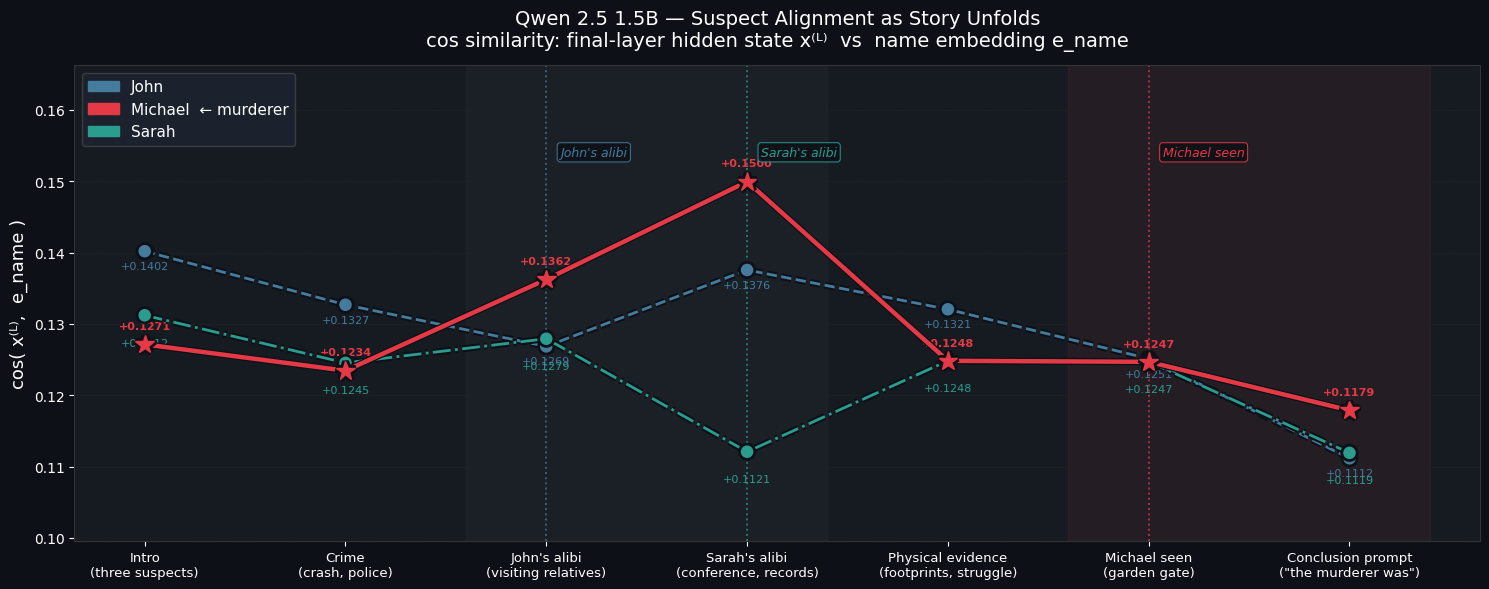

✅ Saved fig_story_alignment.png


In [ ]:
# ── Cell 7: Figure 1 — Alignment as story unfolds ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pfx

x      = np.arange(len(results))
xlbls  = [r['label'] for r in results]

# Key event positions
EVENTS = {
    2: ("John's alibi",   '#457b9d'),
    3: ("Sarah's alibi",  '#2a9d8f'),
    5: ('Michael seen',   '#e63946'),
}

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

LWIDTH = {'John': 2.0, 'Michael': 3.2, 'Sarah': 2.0}
LSTYLE = {'John': '--', 'Michael': '-', 'Sarah': '-.'}
MARKER = {'John': 'o', 'Michael': '*', 'Sarah': 'o'}
MSIZE  = {'John': 8,   'Michael': 14,  'Sarah': 8}

for name in NAMES:
    ys = [r['sims'][name] for r in results]
    ax.plot(x, ys,
            color=PALETTE[name], linewidth=LWIDTH[name],
            linestyle=LSTYLE[name], marker=MARKER[name], markersize=MSIZE[name],
            zorder=5 if name == MURDERER else 3, label=name,
            path_effects=[pfx.withStroke(linewidth=5, foreground='#0d1117')])
    # Value labels at each point
    for xi, yi in enumerate(ys):
        offset = 11 if name == 'Michael' else (-13 if name == 'John' else -22)
        ax.annotate(f'{yi:+.4f}', xy=(xi, yi),
                    xytext=(0, offset), textcoords='offset points',
                    color=PALETTE[name], fontsize=8, ha='center',
                    fontweight='bold' if name == MURDERER else 'normal')

# Y range
all_sims = [r['sims'][n] for r in results for n in NAMES]
ymin, ymax = min(all_sims), max(all_sims)
ypad = (ymax - ymin) * 0.15

# Event verticals + labels
for xi, (elbl, ec) in EVENTS.items():
    ax.axvline(xi, color=ec, linewidth=1.4, linestyle=':', alpha=0.7, zorder=2)
    ax.text(xi + 0.07, ymax + ypad * 0.55, elbl,
            color=ec, fontsize=9, va='bottom', ha='left', style='italic',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#0d1117',
                      edgecolor=ec, alpha=0.85, linewidth=0.8))

# Zone shading
ax.axvspan(1.6, 3.4, alpha=0.04, color='#aaaaaa')   # alibis zone
ax.axvspan(4.6, 6.4, alpha=0.07, color='#e63946')   # Michael implicated
ax.axhline(0, color='#555', linewidth=0.8, linestyle=':', zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(xlbls, color='white', fontsize=9.5)
ax.set_xlim(-0.35, len(results) - 0.35)
ax.set_ylim(ymin - ypad * 2, ymax + ypad * 2.8)
ax.set_ylabel('cos( x⁽ᴸ⁾,  e_name )', color='white', fontsize=13)
ax.set_title(
    'Qwen 2.5 1.5B — Suspect Alignment as Story Unfolds\n'
    'cos similarity: final-layer hidden state x⁽ᴸ⁾  vs  name embedding e_name',
    color='white', fontsize=14, pad=14)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333')
ax.grid(axis='y', color='#222', linestyle='--', linewidth=0.6, zorder=0)

patches = [mpatches.Patch(color=PALETTE[n],
           label=f'{n}{"  ← murderer" if n == MURDERER else ""}') for n in NAMES]
ax.legend(handles=patches, facecolor='#1e2530', edgecolor='#444',
          labelcolor='white', fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('fig_story_alignment.png', dpi=160,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Saved fig_story_alignment.png')

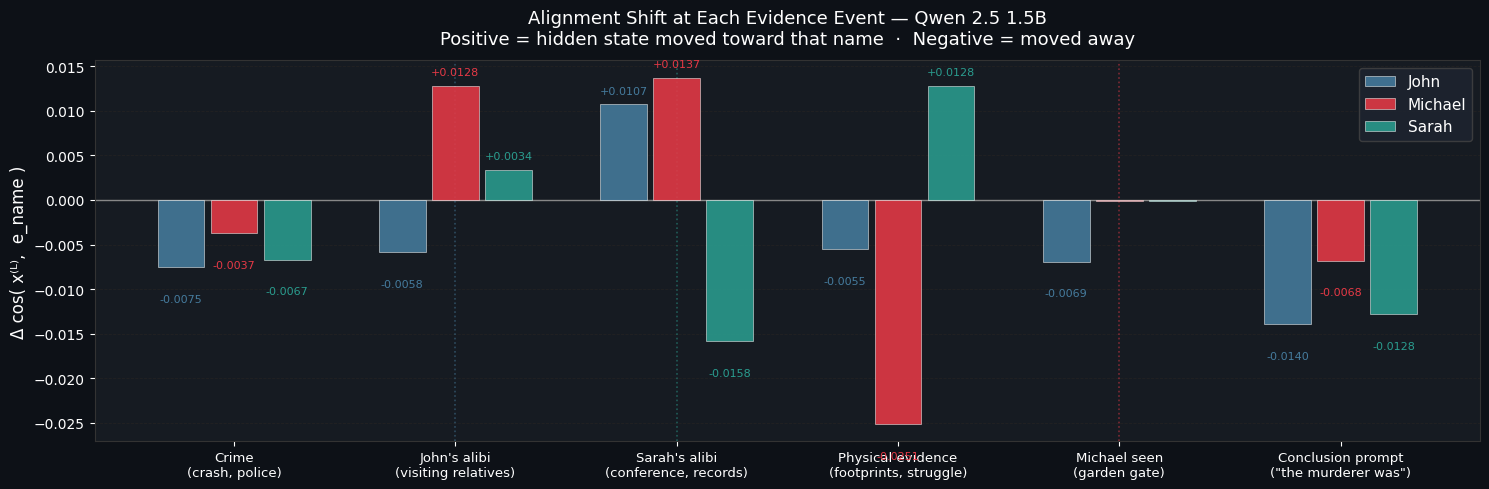

✅ Saved fig_delta_alignment.png


In [ ]:
# ── Cell 8: Figure 2 — Delta shift at each event ─────────────────────────────
fig2, ax2 = plt.subplots(figsize=(15, 5))
fig2.patch.set_facecolor('#0d1117')
ax2.set_facecolor('#161b22')

bw = 0.24
offsets = {'John': -bw, 'Michael': 0, 'Sarah': bw}
x_d    = np.arange(1, len(results))
xlbls_d = [r['label'] for r in results[1:]]

for name in NAMES:
    ys  = [r['sims'][name] for r in results]
    dys = [ys[i] - ys[i-1] for i in range(1, len(ys))]
    bars = ax2.bar(x_d + offsets[name], dys, width=bw * 0.88,
                   color=PALETTE[name], alpha=0.88,
                   edgecolor='white', linewidth=0.4, label=name, zorder=3)
    for bar, dy in zip(bars, dys):
        if abs(dy) > 0.001:
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + (0.001 if dy >= 0 else -0.003),
                     f'{dy:+.4f}',
                     ha='center', va='bottom' if dy >= 0 else 'top',
                     color=PALETTE[name], fontsize=8)

ax2.axhline(0, color='#888', linewidth=1.0, zorder=2)
for xi, (elbl, ec) in EVENTS.items():
    ax2.axvline(xi, color=ec, linewidth=1.2, linestyle=':', alpha=0.5)

ax2.set_xticks(x_d)
ax2.set_xticklabels(xlbls_d, color='white', fontsize=9.5)
ax2.set_ylabel('Δ cos( x⁽ᴸ⁾,  e_name )', color='white', fontsize=12)
ax2.set_title(
    'Alignment Shift at Each Evidence Event — Qwen 2.5 1.5B\n'
    'Positive = hidden state moved toward that name  ·  Negative = moved away',
    color='white', fontsize=13, pad=12)
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_edgecolor('#333')
ax2.grid(axis='y', color='#222', linestyle='--', linewidth=0.6, zorder=0)
ax2.legend(facecolor='#1e2530', edgecolor='#444', labelcolor='white', fontsize=11)

plt.tight_layout()
plt.savefig('fig_delta_alignment.png', dpi=160,
            bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()
print('✅ Saved fig_delta_alignment.png')

In [ ]:
# ── Cell 9: Download outputs ──────────────────────────────────────────────────
from google.colab import files
for fname in ['fig_story_alignment.png', 'fig_delta_alignment.png']:
    files.download(fname)
    print(f'⬇  {fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  fig_story_alignment.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  fig_delta_alignment.png
